# Array Processing Classes Demo

This notebook demonstrates the new array processing classes:

1. **ArrayConfig & ArrayModel**: Configurable antenna arrays with hardware imperfections
2. **ReceivedSignal**: Signal container for antenna array outputs with noise handling

## Features Overview

### ArrayConfig & ArrayModel
- **Multiple array types**: Triangular, linear, circular, custom geometries
- **Hardware imperfections**: Gain/phase errors, mutual coupling, position errors
- **Flexible configuration**: Easy parameter specification and validation
- **Efficient steering vectors**: Cached computation for performance

### ReceivedSignal  
- **Array signal computation**: Automatic steering vector application
- **Flexible noise addition**: SNR-based with multiple noise types
- **Power analysis**: Signal/noise power per element
- **Save/load capability**: Persistent storage for datasets

---


In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import sys

# Add the src directory to Python path
sys.path.append('../src')

from signalgen.array_processing import ArrayConfig, ArrayModel, ReceivedSignal
from signalgen.signal_generator import SignalConfig, SignalGenerator
from visualization.signal_plotting import full_signal_analysis
from visualization.array_plotting import plot_array_geometries, plot_steering_patterns, plot_2d_beampattern, plot_vertical_cut_and_calculate_3db_width
from visualization.recieved_signal_plotting import plot_frequency_domain_comparison, plot_eigenvalue_analysis
# Set up matplotlib for better plots - adjusted for screen fitting
plt.rcParams['figure.figsize'] = (12, 8)  # Reduced from (15, 10) for better screen fit
plt.rcParams['font.size'] = 10  # Slightly smaller font
plt.rcParams['figure.dpi'] = 100  # Standard DPI for better display
plt.rcParams['figure.max_open_warning'] = 20  # Allow more figures

# Enable interactive matplotlib backend for Jupyter notebooks
%matplotlib widget

print("✅ Imports successful! Testing new array processing classes...")


✅ Imports successful! Testing new array processing classes...


## 1. Array Configuration and Models

This section demonstrates the creation of different array types with realistic hardware imperfections:

### Array Types Configured:
- **Triangular Array**: 4 elements with gain/phase errors and mutual coupling
- **Linear Array**: 9 elements with half-wavelength spacing and gain/phase errors  
- **Circular Array**: 6 elements with 0.8λ radius and hardware imperfections
- **Cross Array**: 4 elements in crossed configuration with full imperfections

### Hardware Imperfections Modeled:
- **Gain/Phase Errors**: Random variations in element responses
- **Mutual Coupling**: Inter-element coupling effects
- **Position Errors**: Small random displacements in element positions

Each array operates at 2.4 GHz and includes realistic hardware modeling for accurate DOA estimation testing.


In [2]:
# Create different array configurations
configs = {
    'triangular': ArrayConfig(
        array_type='triangular',
        num_elements=4,
        carrier_freq=2.4e9,
        enable_gain_phase_errors=True,
        enable_mutual_coupling=True,
        position_error_std=0.001,
        
        
        
    ),
    'linear': ArrayConfig(
        array_type='linear',
        num_elements=8,
        carrier_freq=2.4e9,
        element_spacing=0.5,  # Half wavelength
        enable_gain_phase_errors=True,
        enable_mutual_coupling=True,
        position_error_std=0.01, # Less relevant for linear arrays
    ),
    'circular': ArrayConfig(
        array_type='circular',
        num_elements=6,
        carrier_freq=2.4e9,
        radius=0.8,  # 0.8 wavelengths
        enable_gain_phase_errors=True,
        enable_mutual_coupling=True,
        
    ),
    'cross': ArrayConfig(
        array_type='cross',
        num_elements=17,
        carrier_freq=2.4e9,
        enable_gain_phase_errors=True,
        enable_mutual_coupling=True,
        element_spacing=1/3,  # Half wavelength
    )
}

# Create array models
arrays = {}
for name, config in configs.items():
    arrays[name] = ArrayModel(config, seed=42)
    print(f"✅ {name.capitalize()} array: {arrays[name]}")

print(f"\n📏 Wavelength at 2.4 GHz: {arrays['triangular'].wavelength:.3f} m")


✅ Triangular array: ArrayModel(triangular, N=4, f=2.40GHz)
✅ Linear array: ArrayModel(linear, N=8, f=2.40GHz)
✅ Circular array: ArrayModel(circular, N=6, f=2.40GHz)
✅ Cross array: ArrayModel(cross, N=17, f=2.40GHz)

📏 Wavelength at 2.4 GHz: 0.125 m


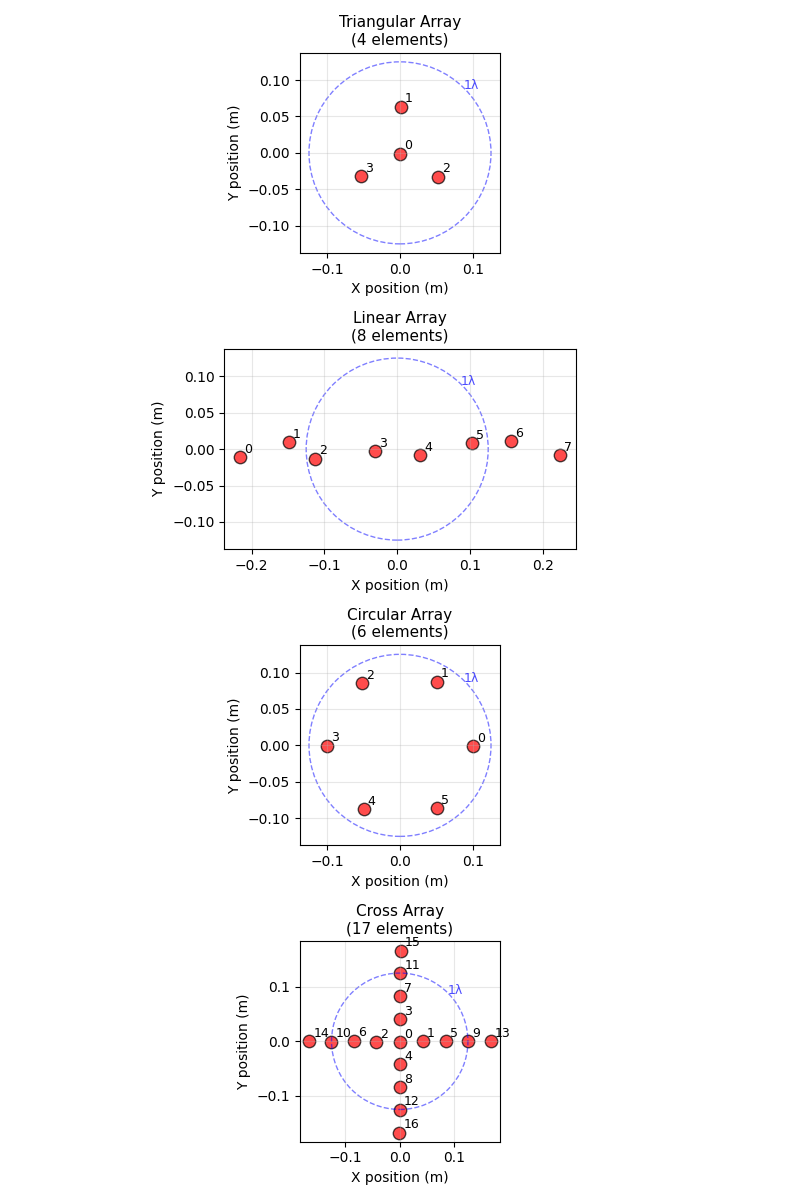

In [3]:
# Visualize array geometries
plot_array_geometries(arrays)

## 2. Steering Vectors and Array Patterns

This section analyzes how arrays respond to signals from different directions and compares ideal vs. realistic array responses.

### Analysis Performed:
- **Steering Vector Calculation**: Compute response for angles from 0° to 359°
- **Ideal vs. Realistic Comparison**: Compare nominal (perfect) vs. actual (imperfect) array responses
- **Magnitude and Phase Patterns**: Visualize how hardware imperfections affect array response
- **Multi-Array Comparison**: Compare steering patterns across different array geometries

### Visualizations:
- **Magnitude Patterns**: Shows how signal amplitude varies with angle for each element
- **Phase Patterns**: Displays phase response variations across angles
- **Directivity Patterns**: Illustrates each array's directional sensitivity

This analysis helps understand how hardware imperfections affect DOA estimation accuracy and provides insights into array selection for different applications.


📊 Hardware imperfections create variation in both magnitude and phase responses


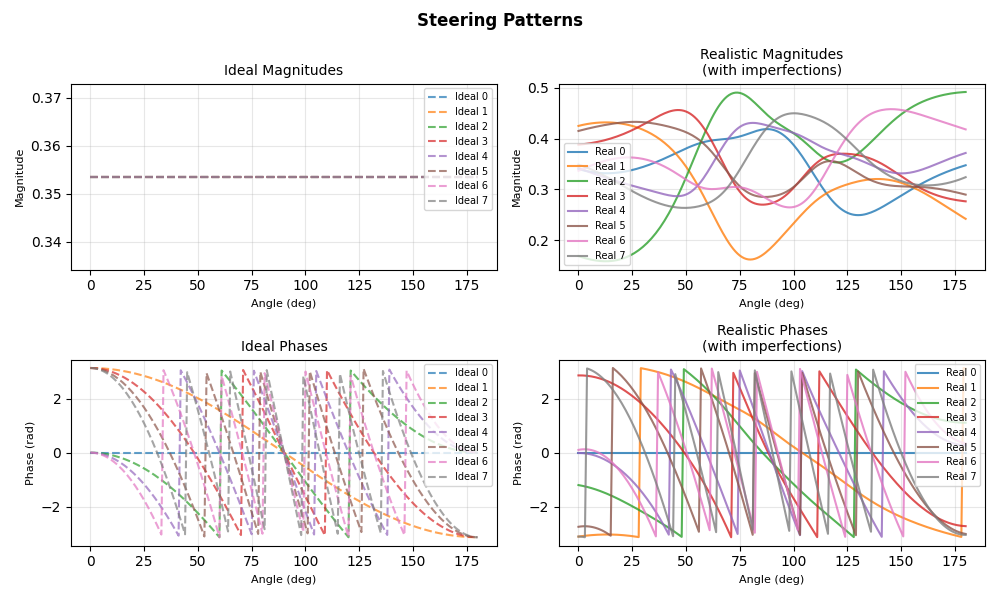

In [4]:
array = arrays['linear']
if array.config.array_type == 'linear':
    angles = np.arange(0, 181, 1)  # Every degree
else:
    angles = np.arange(0, 360, 1)  # Every degree

print("📊 Hardware imperfections create variation in both magnitude and phase responses")
plot_steering_patterns(array, angles)


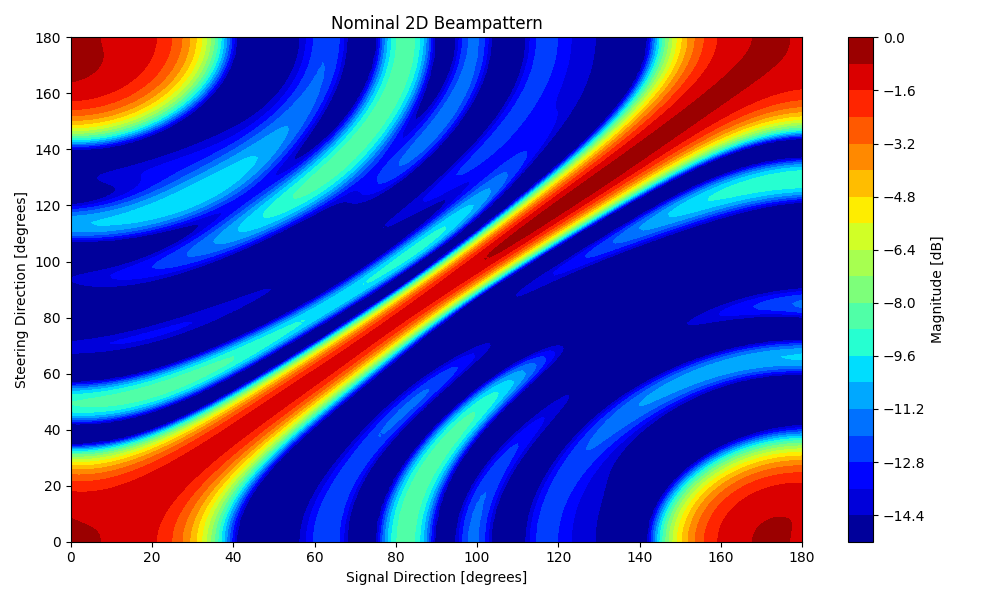

In [5]:
# Beampattern Plotting

A_nominal = array.steering_matrix(angles, nominal=True)
A = array.steering_matrix(angles, nominal=False)

BP = plot_2d_beampattern(A, A_nominal, angles)

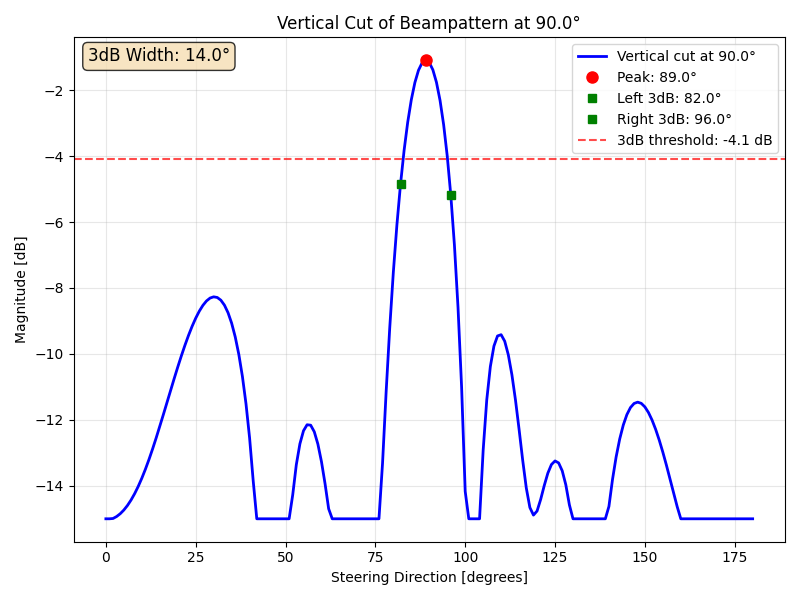

Vertical cut at angle: 90.0°
Peak found at: 89.0° (magnitude: -1.1 dB)
3dB width: 14.0°
3dB points: 82.0° to 96.0°


In [6]:
# Specific cut of beampattern
target_angle = 90
_, _, _ = plot_vertical_cut_and_calculate_3db_width(angles, BP, target_angle)

## 3. Signal Generation and Array Reception

This section demonstrates signal generation and how source signals appear at different antenna arrays after propagation.

### Signal Scenarios Tested:
- **Single Source**: 1 main signal at 96° (100 Hz, 1024 snapshots)
- **Main + Interference**: 2 sources at 60° and 240° (50 Hz & 400 Hz, 8192 snapshots)
- **Complex Multi-Source**: Multiple sources with varying SIR levels

### Signal Processing Chain:
1. **Source Signal Generation**: Create signals with specified frequencies and powers
2. **Array Reception**: Apply steering vectors to simulate signal arrival at each array element
3. **Propagation Effects**: Include realistic signal propagation through the antenna arrays
4. **Power Analysis**: Calculate signal power at each array element

### Array Reception Analysis:
- **Time Domain Signals**: Visualize received signals at each array element
- **Frequency Domain**: Examine spectral content of received signals
- **Power Distribution**: Analyze signal power across array elements
- **Multi-Array Comparison**: Compare how different arrays receive the same signals

This demonstrates the complete signal chain from source generation to array reception, providing realistic data for DOA estimation algorithm testing.


In [7]:
# Scenario 1: 1 main source
config_main_only = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=int(2**22),   # Number of snapshots
    num_sources=1,  # Number of sources
    frequencies=[100],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[96],  # Angles for each source
    use_full_bandwidth=True  # Use full bandwidth
)

# Scenario 2: 1 main source + 1 interference
config_main_1_interference = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=int(2**22),   # Number of snapshots
    num_sources=2,  # Number of sources
    frequencies=[50, 400],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[90, 130],  # Angles for main signal and interference
    sir_db=[0],  # Signal-to-interference ratio
    use_full_bandwidth=True  # Use full bandwidth
)

# Scenario 3: 1 main source + 2 interference
config_main_2_interference = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=100,   # Number of snapshots
    num_sources=3,  # Number of sources
    frequencies=[100, 200, 300],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[90, 45, 135],  # Angles for main signal and interferences
    sir_db=[0, 0],  # Signal-to-interference ratios
    use_full_bandwidth=True  # Use full bandwidth
)

# Scenario 4: 1 main source + 1 multipath
config_main_1_mp = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=1,  # Number of sources
    frequencies=[100],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[96],  # Angles for each source
    enable_multipath=True,  # Enable multipath capability
    use_full_bandwidth=True  # Use full bandwidth
)

# Scenario 5: 1 main source + 2 multipath
config_main_2_mp = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=1024,   # Number of snapshots
    num_sources=1,  # Number of sources
    frequencies=[100],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[96],  # Angles for each source
    enable_multipath=True,  # Enable multipath capability
    use_full_bandwidth=True  # Use full bandwidth
)

# Scenario 6: 1 main source + 1 interference + 1 multipath
config_main_1_interference_1_mp = SignalConfig(
    fs=1e3,  # Sampling frequency
    T=200,   # Number of snapshots
    num_sources=2,  # Number of sources
    frequencies=[100, 200],  # Frequencies for each source
    main_source_power=0,  # Amplitudes for each source
    angles=[96, 45],  # Angles for main signal and interference
    sir_db=[0],  # Signal-to-interference ratio
    enable_multipath=True,  # Enable multipath capability
    use_full_bandwidth=True  # Use full bandwidth
)

# Initialize signal generators for all scenarios
generator_main_only = SignalGenerator(config_main_only)
generator_main_1_interference = SignalGenerator(config_main_1_interference)
generator_main_2_interference = SignalGenerator(config_main_2_interference)
generator_main_1_mp = SignalGenerator(config_main_1_mp)
generator_main_2_mp = SignalGenerator(config_main_2_mp)
generator_main_1_interference_1_mp = SignalGenerator(config_main_1_interference_1_mp)

# Generate time axis
t = generator_main_only.generate_time_axis()

# Generate source signals for all scenarios
signals_main_only = generator_main_only.generate_source_signals(t)
signals_main_1_interference = generator_main_1_interference.generate_source_signals(t)
signals_main_2_interference = generator_main_2_interference.generate_source_signals(t)

# Generate signals for multipath scenarios
signals_main_1_mp = generator_main_1_mp.generate_source_signals(t)
signals_main_2_mp = generator_main_2_mp.generate_source_signals(t)
signals_main_1_interference_1_mp = generator_main_1_interference_1_mp.generate_source_signals(t)

# Add multipath effects to multipath scenarios
signals_main_1_mp = generator_main_1_mp.add_multipath(signals_main_1_mp, t, config_main_1_mp.fs, 2.4e9, config_main_1_mp.fs/2, num_multipath_components=1)
signals_main_2_mp = generator_main_2_mp.add_multipath(signals_main_2_mp, t, config_main_2_mp.fs, 2.4e9, config_main_2_mp.fs/2, num_multipath_components=2)
signals_main_1_interference_1_mp = generator_main_1_interference_1_mp.add_multipath(signals_main_1_interference_1_mp, t, config_main_1_interference_1_mp.fs, 2.4e9, config_main_1_interference_1_mp.fs/2, num_multipath_components=1)


In [8]:
signal= signals_main_only    
signal_config = config_main_only

In [9]:
signal.shape

(1, 4194304)


🚀 Starting Full Analysis: Signal Analysis
📊 Signal Shape: (1, 4194304)


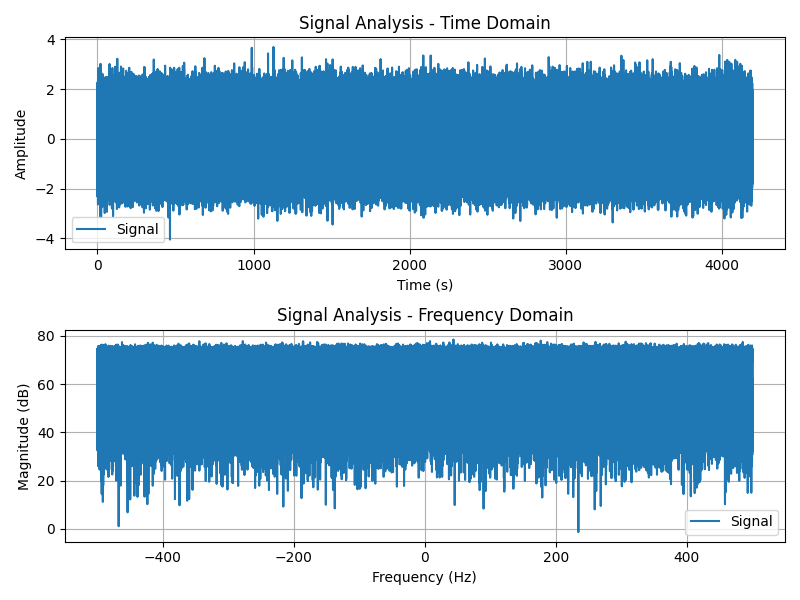

⚠️  Signal Analysis: Only 1 source(s) - skipping correlation analysis


In [ ]:
full_signal_analysis(signal, t, config_main_1_mp.fs)

## 4. Adding Noise with Different SNR Levels

This section demonstrates the comprehensive noise modeling capabilities of the ReceivedSignal class and analyzes how noise affects signal reception.

### SNR Levels Tested:
- **High SNR**: 30 dB, 20 dB (clean conditions)
- **Medium SNR**: 10 dB, 5 dB (moderate noise)
- **Low SNR**: 0 dB, -5 dB (challenging conditions)

### Noise Analysis Features:
- **Precise SNR Control**: Accurate noise power adjustment per element
- **Gaussian Noise**: Additive white Gaussian noise modeling
- **Per-Element SNR**: Individual SNR measurement for each array element
- **Power Validation**: Verification of actual vs. target SNR levels

### Comprehensive Visualizations:
- **Time Domain Comparison**: Clean vs. noisy signal visualization
- **Frequency Domain Analysis**: Spectral content at different SNR levels
- **Signal Quality Assessment**: SNR impact on signal characteristics
- **Multi-Element Analysis**: Noise effects across all array elements

This analysis provides essential insights into how noise affects DOA estimation performance and helps establish realistic SNR ranges for algorithm testing and dataset generation.

In [370]:
from signalgen.array_processing import ReceivedSignal
steering_matrix = array.steering_matrix(signal_config.angles, nominal=True)
x = ReceivedSignal(steering_matrix, signal, signal_config.angles, signal_config)
clean_signal = x.array_signals.copy()
noisy_object = x.add_noise(snr_db=-10, source_frequencies=signal_config.frequencies, signal_bandwidth=signal_config.bandwidth, sampling_frequency=signal_config.fs)
noise = noisy_object.noise.copy()
noisy_signal = noisy_object.array_signals.copy()

/Users/itamaralmog/Documents/Masters/Second Year/All_DOA_nets/Tri4Net/notebooks/../src/visualization/recieved_signal_plotting.py:52: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/itamaralmog/miniconda3/envs/DOA_env/lib/python3.11/site-packages/ipympl/backend_nbagg.py:335: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.figure.savefig(buf, format='png', dpi='figure')


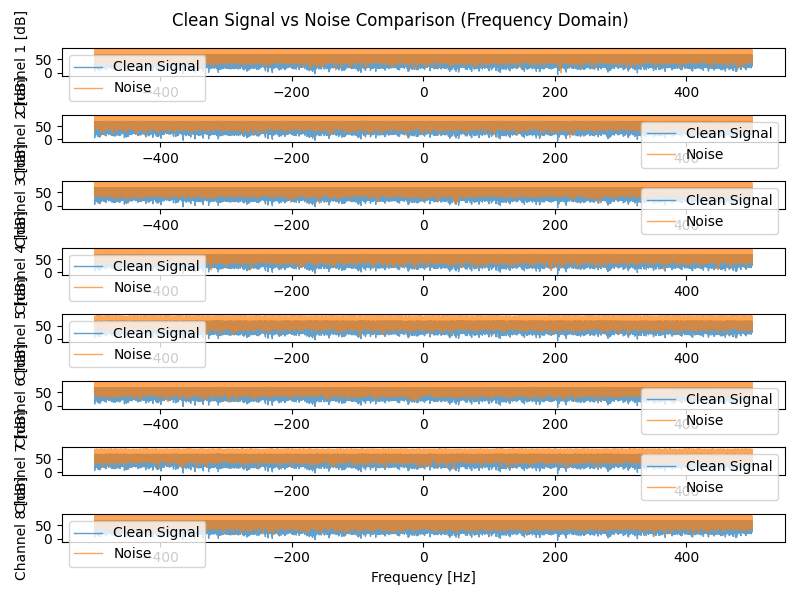

In [371]:
# Plot frequency domain comparison

plot_frequency_domain_comparison(clean_signal, noise, signal_config)

(8, 8)

Main eigenvalue: 11.099074
Sum of smaller eigenvalues: 70.715691
Ratio (main/smaller): 0.156953
Ratio in dB: -8.04 dB


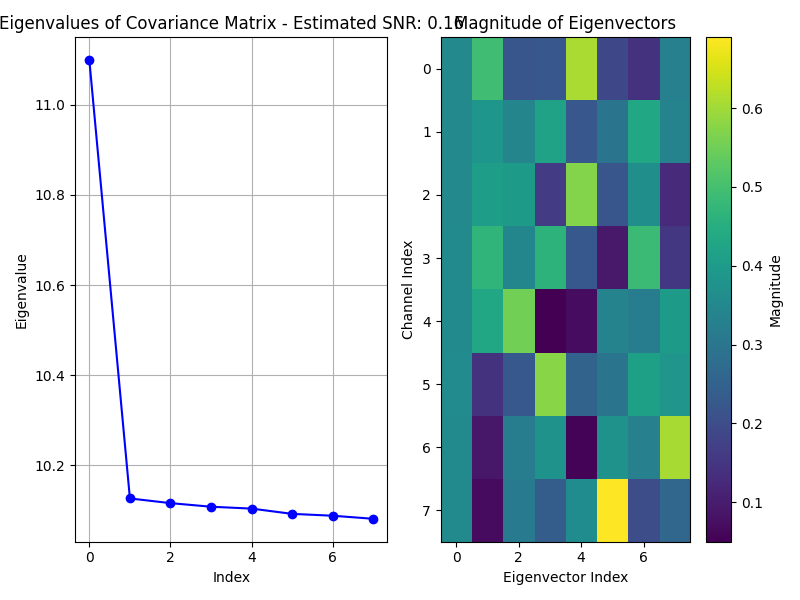

In [372]:
# Eigenvalue analysis

plot_eigenvalue_analysis(noisy_signal, signal_config.num_sources)

In [373]:
# ==========================================
# Covariance Matrix Comparison
# ==========================================
# Compare empirical covariance (from noisy signal) vs theoretical covariance (R_x = AR_s A^H + σ²I_M)

import numpy as np
import matplotlib.pyplot as plt

print("🔍 Covariance Matrix Comparison Analysis")
print("="*50)

# 1. Calculate empirical covariance matrix from noisy signal
R_x_empirical = np.cov(noisy_signal)
print(f"Empirical covariance matrix shape: {R_x_empirical.shape}")

# 2. Calculate signal covariance matrix R_s from source signals
R_s = np.cov(signal)
print(f"Signal covariance matrix R_s shape: {R_s.shape}")
print(f"Signal covariance matrix R_s:\n{R_s}")

# 3. Get steering matrix A for the signal angles
A = steering_matrix  # Already calculated for the signal angles
print(f"Steering matrix A shape: {A.shape}")

# 4. Calculate noise variance σ² from the noise
noise_variance = np.mean(np.abs(noise)**2)  # Average noise power across all elements
signal_variance = np.mean(np.abs(signal)**2)

print(f"Noise variance σ²: {noise_variance:.6f}")
print(f"Signal variance σ²: {signal_variance:.6f}")
# 5. Calculate theoretical covariance matrix: R_x = AR_s A^H + σ²I_M
M = A.shape[0]  # Number of array elements
I_M = np.eye(M)  # Identity matrix
A_H = A.conj().T  # Conjugate transpose of steering matrix

R_x_theoretical = A @ R_s @ A_H + (noise_variance)* (I_M)
print(f"Theoretical covariance matrix shape: {R_x_theoretical.shape}")

# 6. Calculate difference between empirical and theoretical
R_x_diff = R_x_empirical - R_x_theoretical
frobenius_error = np.linalg.norm(R_x_diff, 'fro')
relative_error = frobenius_error / np.linalg.norm(R_x_empirical, 'fro')

print(f"\nComparison Results:")
print(f"Frobenius norm of difference: {frobenius_error:.6f}")
print(f"Relative error: {relative_error:.6f} ({relative_error*100:.4f}%)")

# 7. Visualization
fig, axes = plt.subplots(2, 3, figsize=(8, 6))
fig.suptitle('Covariance Matrix Comparison: Empirical vs Theoretical', fontsize=14)

# Plot magnitudes
vmin = min(np.abs(R_x_empirical).min(), np.abs(R_x_theoretical).min())
vmax = max(np.abs(R_x_empirical).max(), np.abs(R_x_theoretical).max())

# Row 1: Magnitude plots
im1 = axes[0,0].imshow(np.abs(R_x_empirical), cmap='viridis', vmin=vmin, vmax=vmax)
axes[0,0].set_title('|R_x Empirical|')
axes[0,0].set_xlabel('Array Element')
axes[0,0].set_ylabel('Array Element')
plt.colorbar(im1, ax=axes[0,0])

im2 = axes[0,1].imshow(np.abs(R_x_theoretical), cmap='viridis', vmin=vmin, vmax=vmax)
axes[0,1].set_title('|R_x Theoretical|')
axes[0,1].set_xlabel('Array Element')
axes[0,1].set_ylabel('Array Element')
plt.colorbar(im2, ax=axes[0,1])

im3 = axes[0,2].imshow(np.abs(R_x_diff), cmap='RdBu_r')
axes[0,2].set_title('|Difference|')
axes[0,2].set_xlabel('Array Element')
axes[0,2].set_ylabel('Array Element')
plt.colorbar(im3, ax=axes[0,2])

# Row 2: Phase plots
phase_empirical = np.angle(R_x_empirical)
phase_theoretical = np.angle(R_x_theoretical)
phase_diff = np.angle(R_x_diff)

im4 = axes[1,0].imshow(phase_empirical, cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[1,0].set_title('Phase(R_x Empirical)')
axes[1,0].set_xlabel('Array Element')
axes[1,0].set_ylabel('Array Element')
plt.colorbar(im4, ax=axes[1,0])

im5 = axes[1,1].imshow(phase_theoretical, cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[1,1].set_title('Phase(R_x Theoretical)')
axes[1,1].set_xlabel('Array Element')
axes[1,1].set_ylabel('Array Element')
plt.colorbar(im5, ax=axes[1,1])

im6 = axes[1,2].imshow(phase_diff, cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[1,2].set_title('Phase(Difference)')
axes[1,2].set_xlabel('Array Element')
axes[1,2].set_ylabel('Array Element')
plt.colorbar(im6, ax=axes[1,2])

plt.tight_layout()
plt.show()

# 8. Diagonal comparison (main diagonal elements)
print(f"\nDiagonal Elements Comparison:")
print(f"Empirical diagonal: {np.abs(np.diag(R_x_empirical))}")
print(f"Theoretical diagonal: {np.abs(np.diag(R_x_theoretical))}")
print(f"Diagonal difference: {np.abs(np.diag(R_x_diff))}")

# 9. Eigenvalue comparison
eigenvals_emp, _ = np.linalg.eigh(R_x_empirical)
eigenvals_theo, _ = np.linalg.eigh(R_x_theoretical)
eigenvals_emp = np.sort(np.abs(eigenvals_emp))[::-1]
eigenvals_theo = np.sort(np.abs(eigenvals_theo))[::-1]

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(eigenvals_emp, 'bo-', label='Empirical', markersize=8)
plt.plot(eigenvals_theo, 'rs-', label='Theoretical', markersize=8)
plt.title('Eigenvalues Comparison')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue Magnitude')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(eigenvals_emp - eigenvals_theo, 'go-', markersize=8)
plt.title('Eigenvalue Differences')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Difference')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\nEigenvalue Analysis:")
print(f"Empirical eigenvalues: {eigenvals_emp}")
print(f"Theoretical eigenvalues: {eigenvals_theo}")
print(f"Eigenvalue differences: {eigenvals_emp - eigenvals_theo}")

# 10. Summary statistics
print(f"\n📊 Summary Statistics:")
print(f"Mean absolute error: {np.mean(np.abs(R_x_diff)):.6f}")
print(f"Max absolute error: {np.max(np.abs(R_x_diff)):.6f}")
print(f"RMS error: {np.sqrt(np.mean(np.abs(R_x_diff)**2)):.6f}")
print(f"Condition number (empirical): {np.linalg.cond(R_x_empirical):.2f}")
print(f"Condition number (theoretical): {np.linalg.cond(R_x_theoretical):.2f}")

print("\n✅ Covariance matrix comparison complete!")

🔍 Covariance Matrix Comparison Analysis
Empirical covariance matrix shape: (8, 8)
Signal covariance matrix R_s shape: ()
Signal covariance matrix R_s:
(1.0000000038813337+5.014436243280222e-19j)
Steering matrix A shape: (8, 1)
Noise variance σ²: 10.101873
Signal variance σ²: 1.000000


ValueError: matmul: Input operand 1 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)

difference between clean and noisy 5.4018864148051495


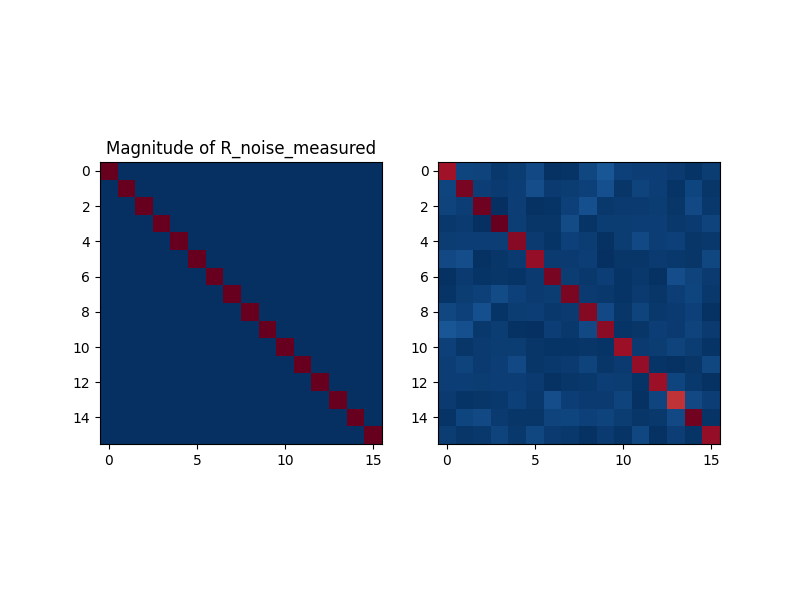

In [345]:
R_x_clean = A @ R_s @ A_H
R_x_noisy = np.cov(x.array_signals)
R_noise = (noise_variance)* (I_M)
R_noise_measur = np.cov(noise)
print('difference between clean and noisy', np.linalg.norm(R_noise - R_noise_measur, 'fro'))
plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
plt.title('Magnitude of R_noise')
plt.imshow(np.abs(R_noise), cmap='RdBu_r')
# plt.colorbar()
plt.title('Magnitude of R_noise_measured')
plt.subplot(1, 2, 2)
plt.imshow(np.abs(R_noise_measur), cmap='RdBu_r')

## 5. Conclusion and Applications

This notebook successfully demonstrates the complete array processing pipeline with realistic hardware modeling. The key achievements include:

### 🎯 Core Capabilities Demonstrated:
- **Multi-Array Support**: Triangular, linear, circular, and cross array configurations
- **Realistic Hardware Modeling**: Comprehensive imperfection modeling including gain/phase errors, mutual coupling, and position uncertainties
- **Flexible Signal Generation**: Support for single and multi-source scenarios with configurable SIR levels
- **Advanced Noise Modeling**: Precise SNR control with gaussian noise addition and per-element analysis

### 📊 Analysis Features:
- **Steering Vector Analysis**: Comparison of ideal vs. realistic array responses
- **Signal Reception Modeling**: Complete propagation chain from source to array elements
- **Noise Impact Assessment**: Comprehensive SNR analysis across different conditions
- **Multi-Array Comparison**: Performance evaluation across different array geometries

### 🚀 Applications:
This framework is ideal for:
- **Algorithm Development**: Testing DOA estimation algorithms under realistic conditions
- **Dataset Generation**: Creating comprehensive training datasets for machine learning models
- **Performance Benchmarking**: Comparing algorithms across different array configurations and noise conditions
- **System Design**: Optimizing array geometry and hardware specifications

The modular design allows easy extension to new array types, imperfection models, and signal scenarios, making it a powerful tool for array processing research and development.
